## Testing Double EM: Steep then CG


In [59]:
import numpy as np
import matplotlib.pyplot as plt

folderdir = "pots/"
twists = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07]
n_tws = len(twists)

pots = [[] for i in range(n_tws)]
steps = [[] for i in range(n_tws)]
pots2 = [[] for i in range(n_tws)]
steps2 = [[] for i in range(n_tws)]

pots_tot = [[] for i in range(n_tws)]
steps_tot = [[] for i in range(n_tws)]

# Line to unpack .xvg generated by GROMACS
for i in range(n_tws):
    steps[i], pots[i] = np.loadtxt(folderdir + f"pot-tw{twists[i]}.xvg",comments=["@","#"],unpack=True)
    steps2[i], pots2[i] = np.loadtxt(folderdir + f"pot2-tw{twists[i]}.xvg",comments=["@","#"],unpack=True)

    # Join them in the general one
    steps_tot[i], pots_tot[i] = np.concatenate([steps[i], steps2[i] + steps[i][-1]]), np.concatenate([pots[i], pots2[i]])


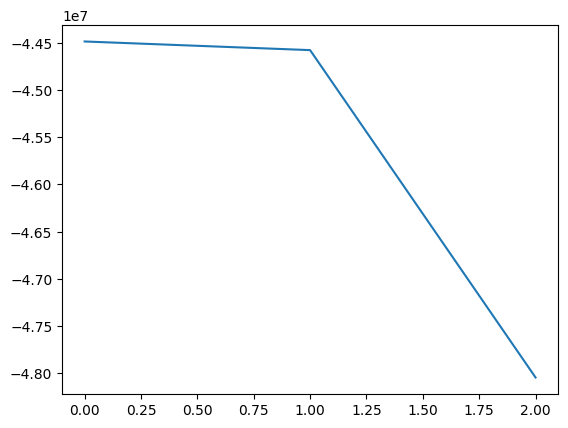

In [55]:
plt.plot(pots2[-1])

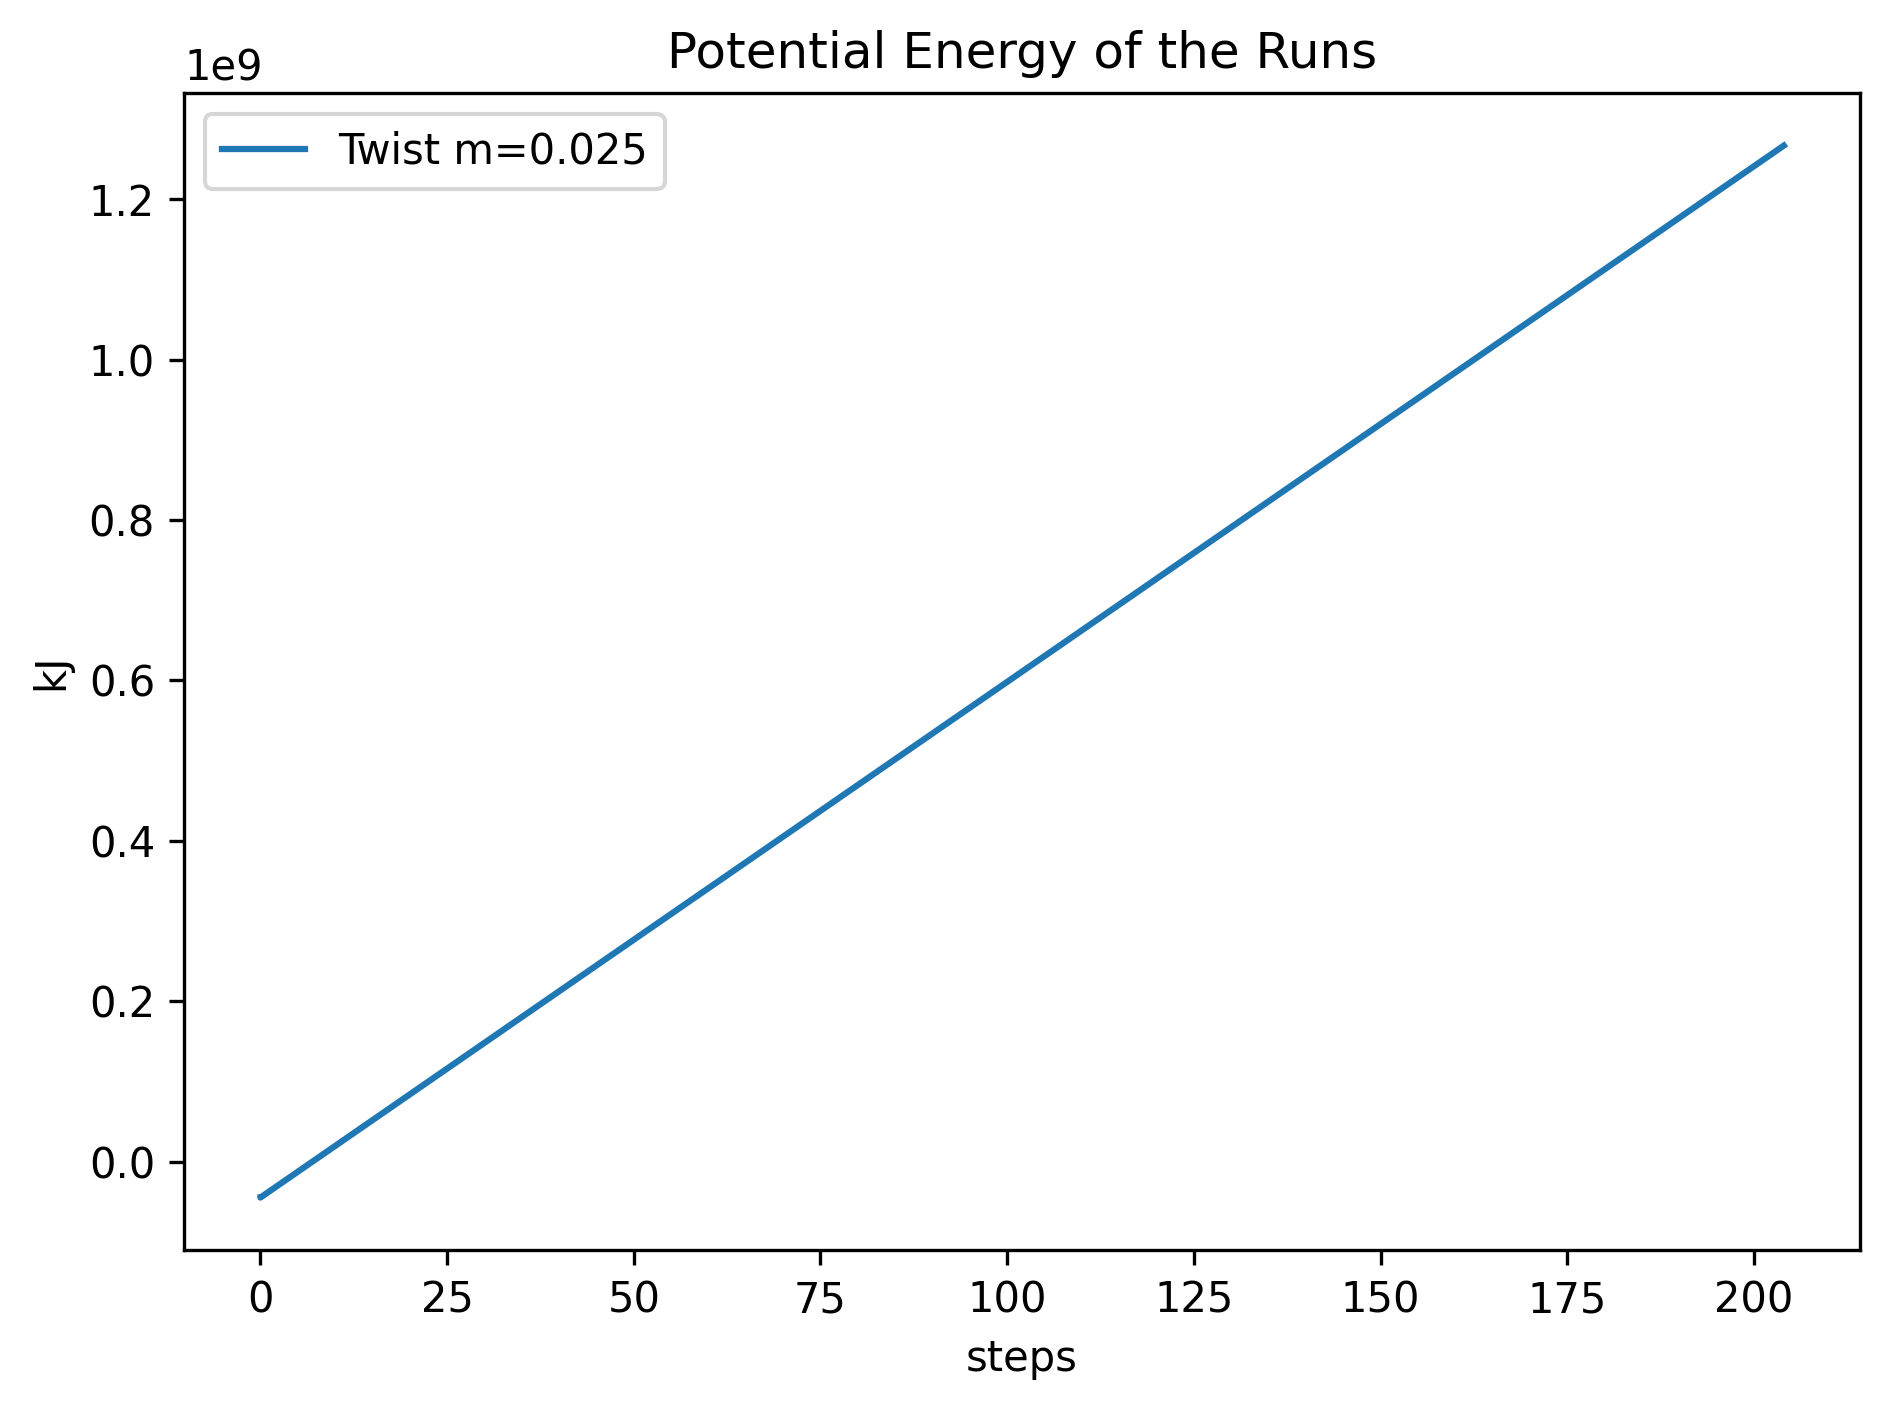

In [58]:
plt.figure(dpi=300)

# --- Normal Plotting ---
initial_step = 20
idx_tw = 4
# BAD CG id: 4, 7 

# ene_plot = pots_tot[idx_tw][initial_step:-1]
# steps_plot = steps_tot[idx_tw][initial_step:-1]
# plt.plot(steps_plot, ene_plot, label=f"Twist m={twists[idx_tw]}")

plt.plot(steps2[idx_tw], pots2[idx_tw], label=f"Twist m={twists[idx_tw]}")

plt.xlabel("steps")
plt.ylabel("kJ")
plt.title("Potential Energy of the Runs")

plt.legend()
plt.tight_layout()
plt.show()

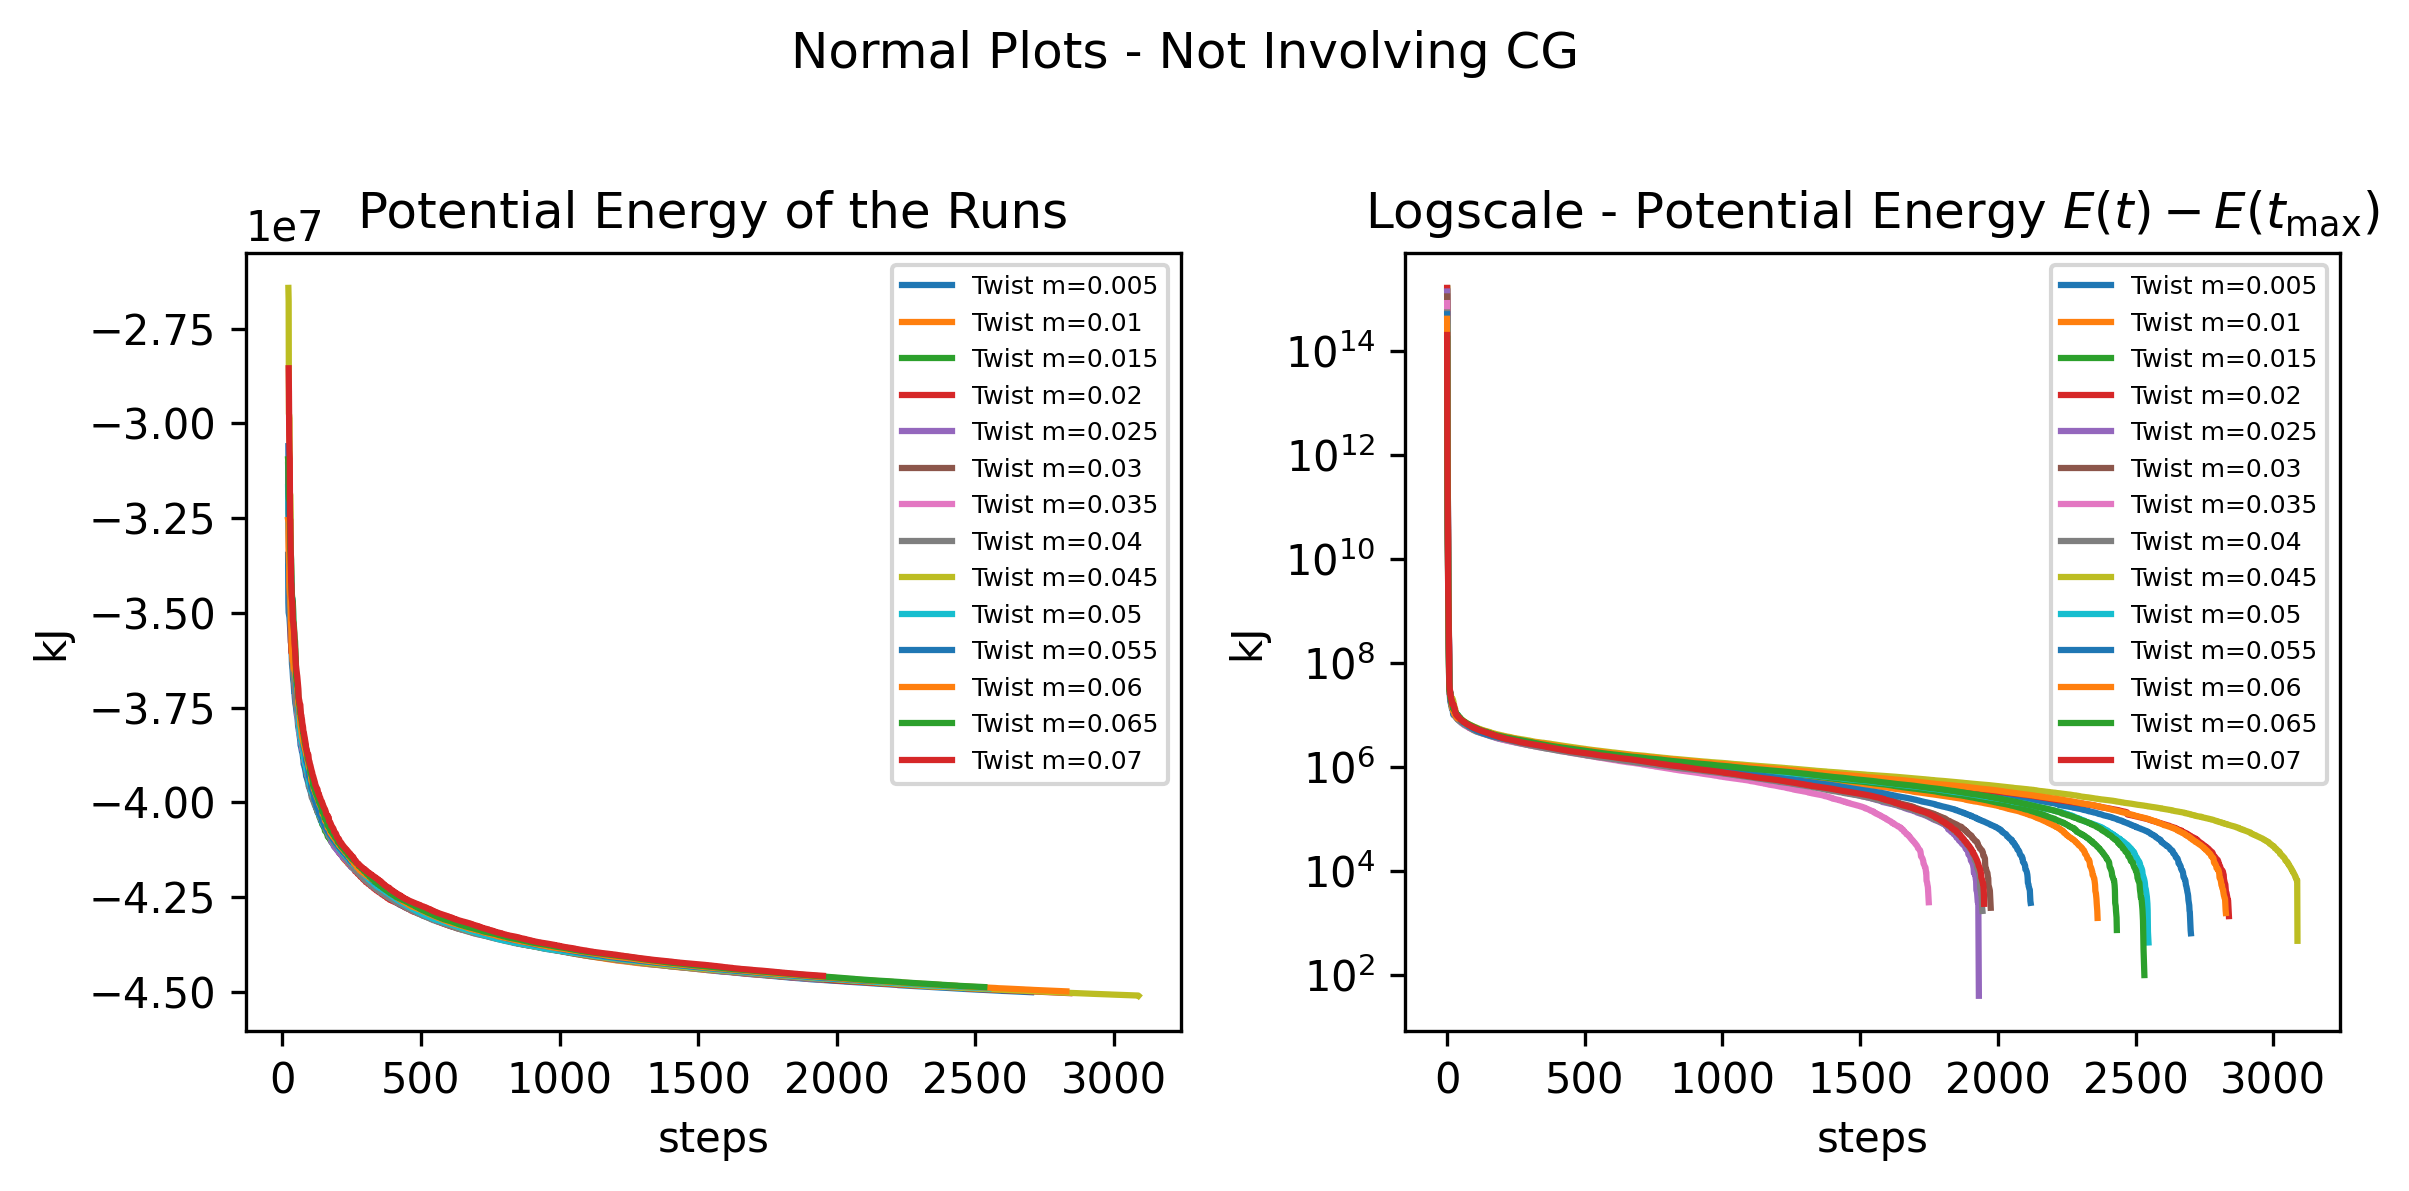

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# --- Normal Plotting ---
initial_step = 20

for i in range(n_tws):
    ene_plot = pots[i][initial_step:-1]
    steps_plot = steps[i][initial_step:-1]
    ax[0].plot(steps_plot, ene_plot, label=f"Twist m={twists[i]}")

ax[0].set_xlabel("steps")
ax[0].set_ylabel("kJ")
ax[0].set_title("Potential Energy of the Runs")
ax[0].legend(fontsize=6)

# --- Log Scale ---
ene_norm = [pots[i] - pots[i][-1] for i in range(n_tws)]

initial_step = 0

for i in range(n_tws):
    ene_plot = ene_norm[i][initial_step:-1]
    steps_plot = steps[i][initial_step:-1]
    ax[1].semilogy(steps_plot, ene_plot, label=f"Twist m={twists[i]}")

ax[1].set_xlabel("steps")
ax[1].set_ylabel("kJ")
ax[1].set_title(r"Logscale - Potential Energy $E(t) - E(t_\text{max})$")
ax[1].legend(fontsize=6)

plt.suptitle("Normal Plots - Not Involving CG")
plt.tight_layout()
plt.show()

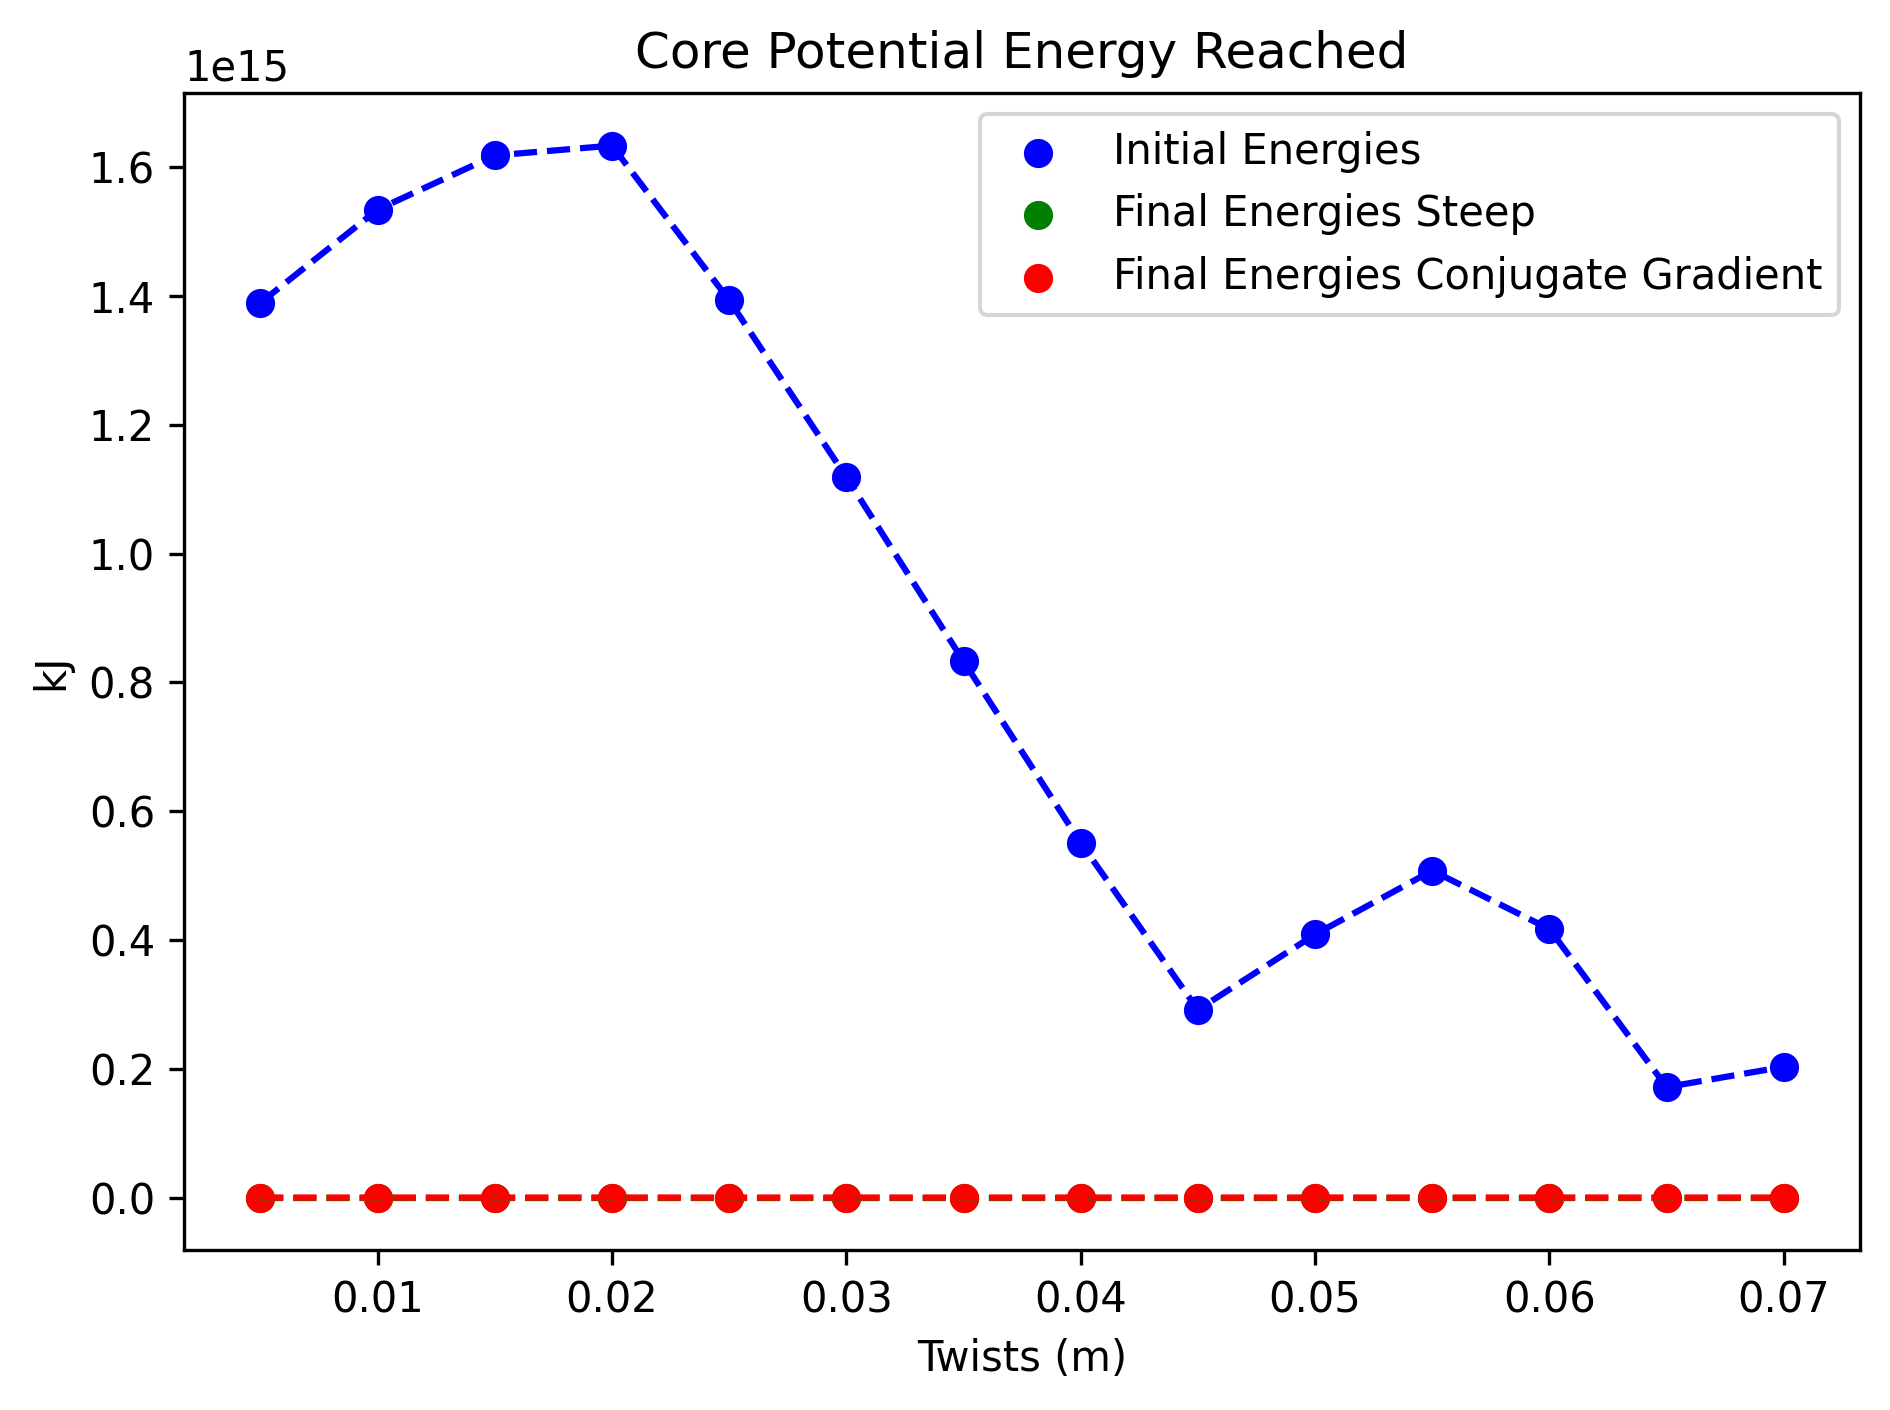

In [53]:
ini_enes = [pots[i][0] for i in range(n_tws)]
fin_enes_stp = [pots[i][-1] for i in range(n_tws)]
fin_enes_cg = [pots2[i][-1] for i in range(n_tws)]

colors = ["b", "g", "r"]

plt.figure(dpi=300)

plt.scatter(twists, ini_enes, label = "Initial Energies", color="b")
plt.plot(twists, ini_enes, color="b", linestyle="dashed")

plt.scatter(twists, fin_enes_stp, label = "Final Energies Steep", color="g")
plt.plot(twists, fin_enes_stp, color="g", linestyle="dashed")

plt.scatter(twists, fin_enes_cg, label = "Final Energies Conjugate Gradient", color="r")
plt.plot(twists, fin_enes_cg, color="r", linestyle="dashed")

plt.xlabel("Twists (m)")
plt.ylabel("kJ")
plt.title("Core Potential Energy Reached")

plt.legend()
plt.tight_layout()
plt.show()

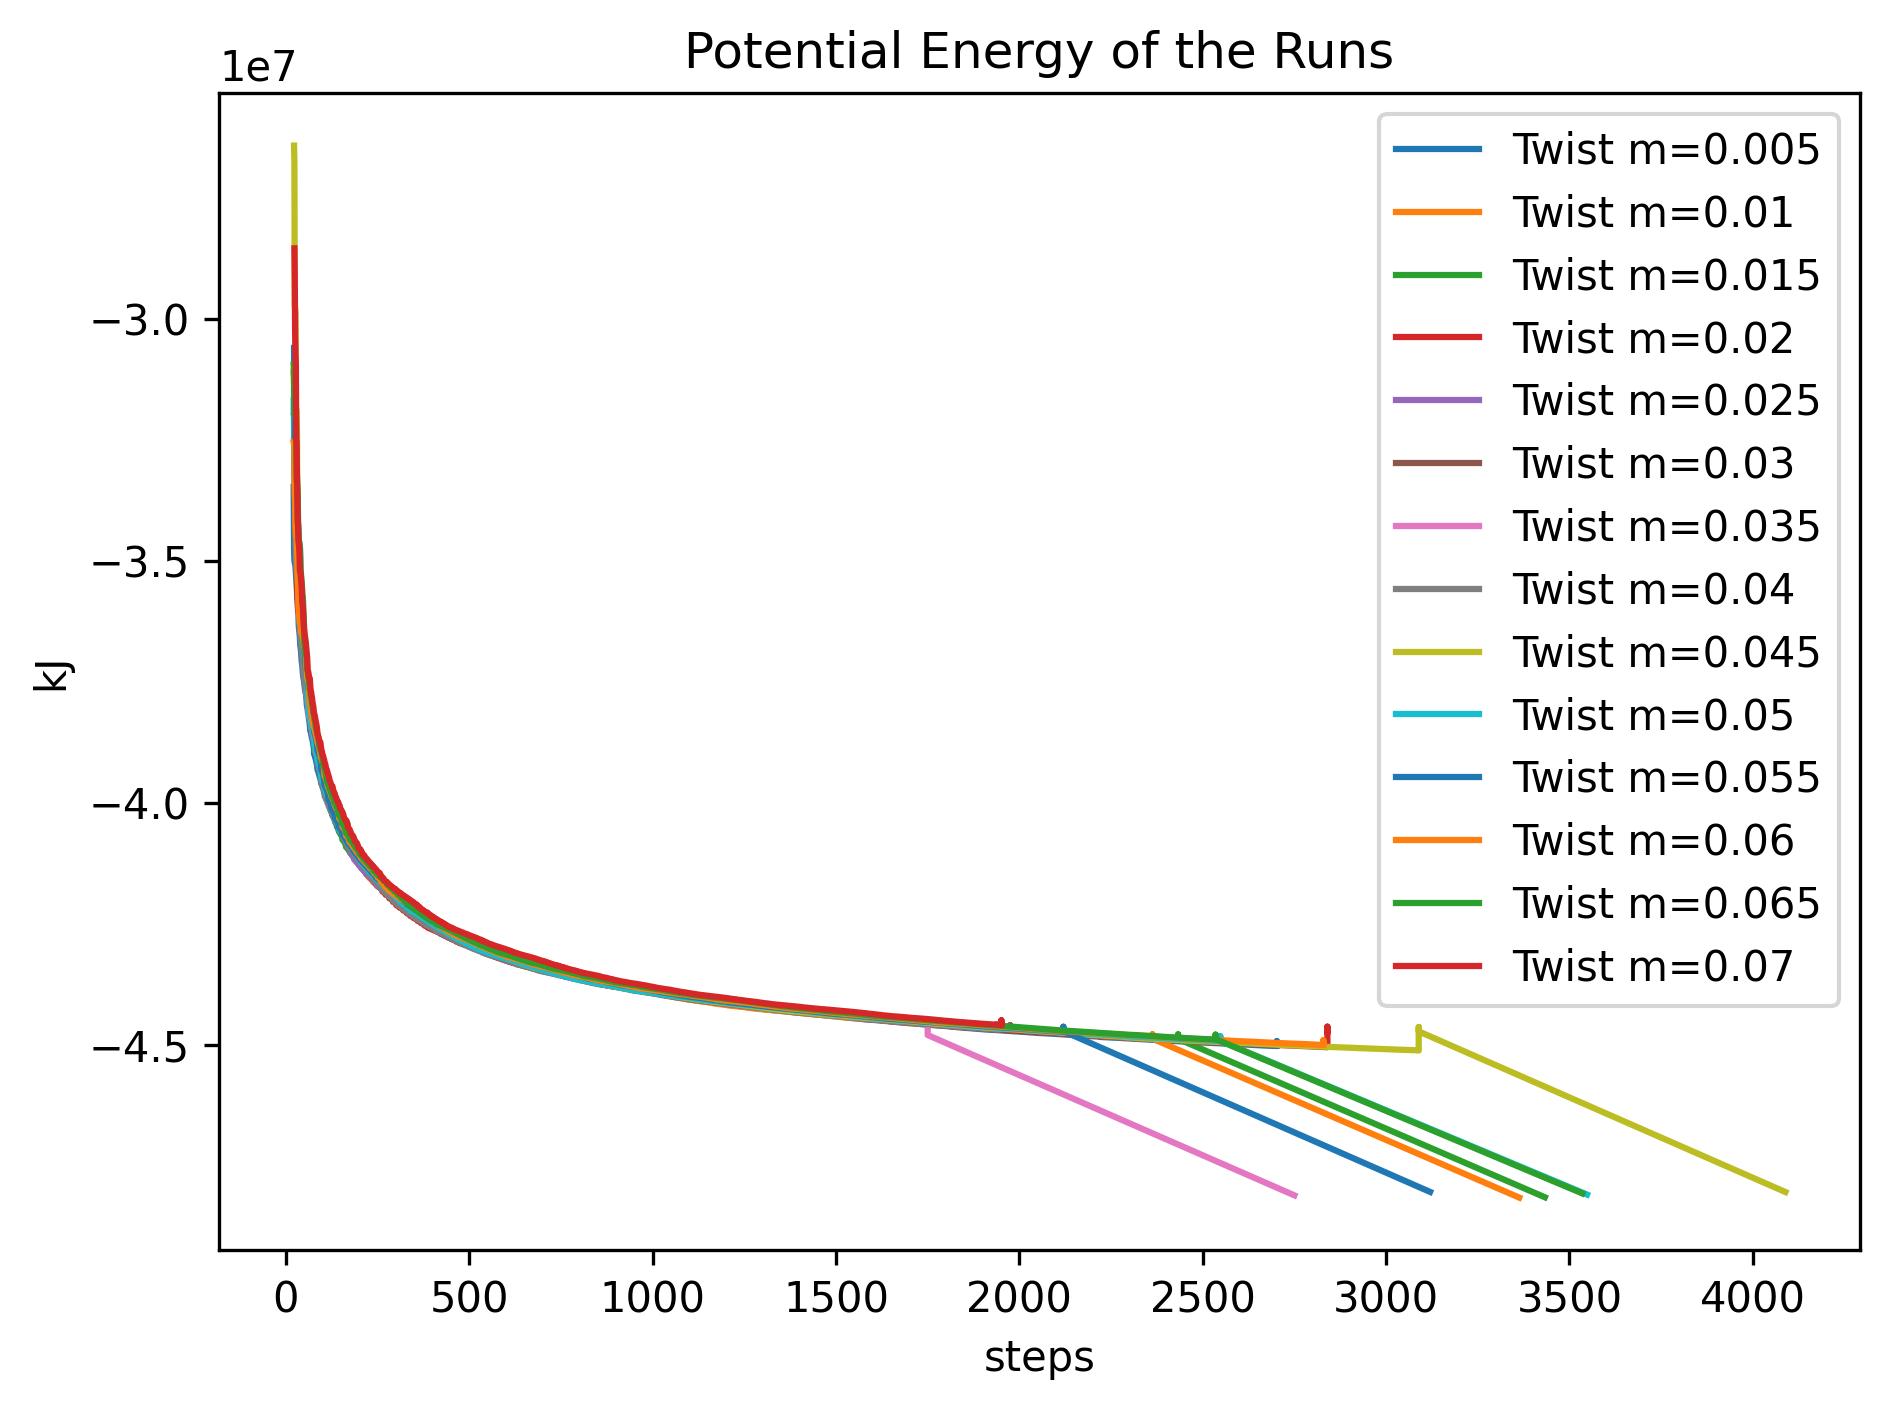

In [60]:
plt.figure(dpi=300)

# --- Normal Plotting ---
initial_step = 20

for i in range(n_tws):
    ene_plot = pots_tot[i][initial_step:-1]
    steps_plot = steps_tot[i][initial_step:-1]
    plt.plot(steps_plot, ene_plot, label=f"Twist m={twists[i]}")

plt.xlabel("steps")
plt.ylabel("kJ")
plt.title("Potential Energy of the Runs")

plt.legend()
plt.tight_layout()
plt.show()

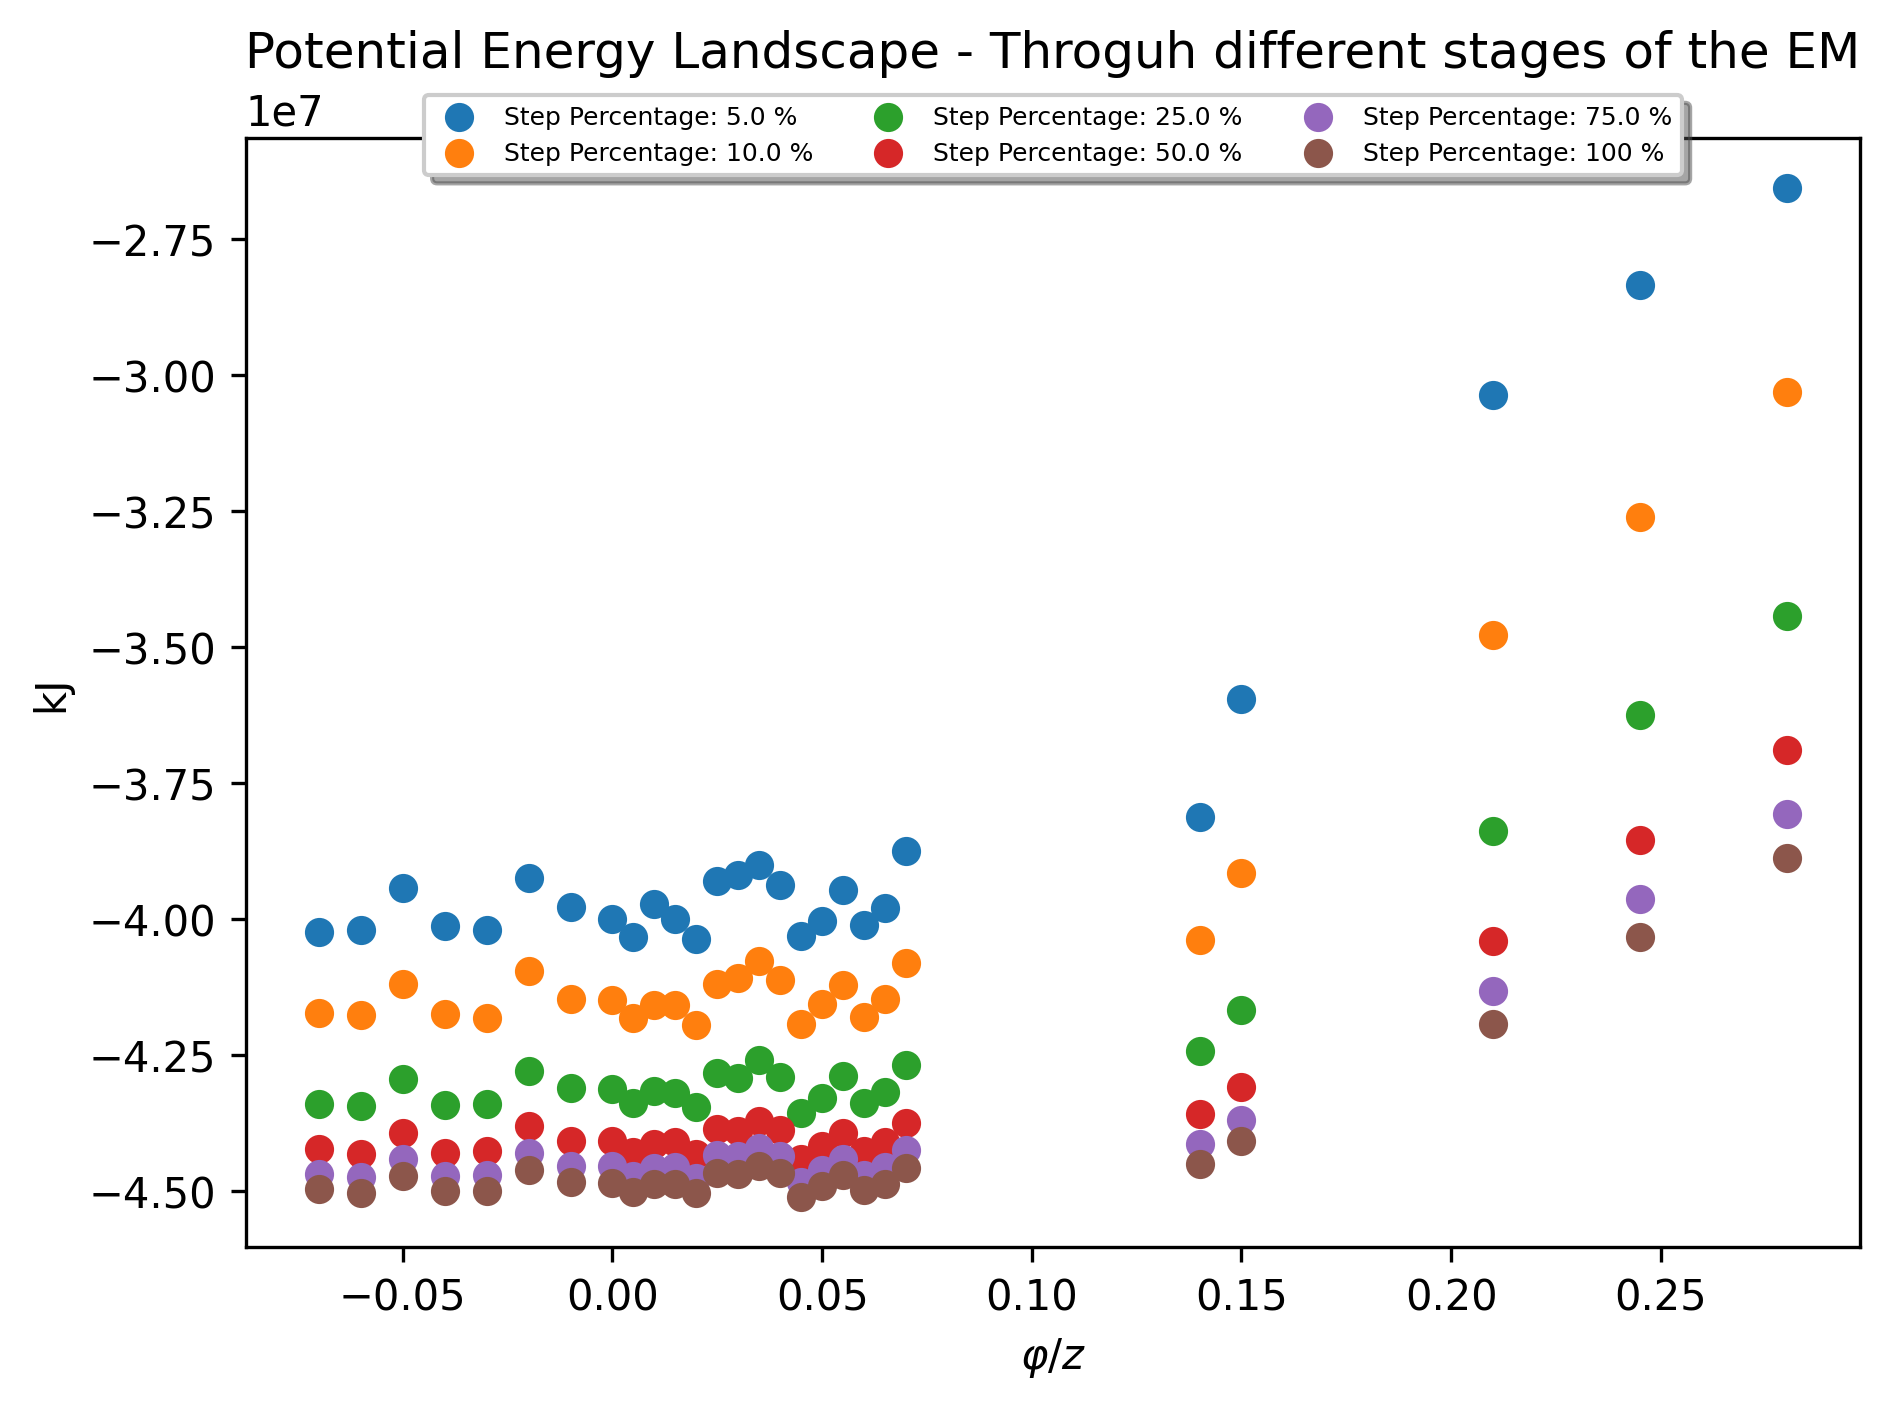

In [8]:
perc = [0.05, 0.1, 0.25, 0.5, 0.75, 1]
plt.figure(dpi=300)

for percentage in perc:
    if percentage == 0:
        energies = [pots[i][0] for i in range(n_tws)]
    else:
        energies = [pots[i][int(percentage * len(steps[i])) - 1] for i in range(n_tws)]
    plt.scatter(twists, energies, label = f'Step Percentage: {percentage*100} %')

plt.xlabel(r'$\varphi/z$')
plt.ylabel('kJ')
plt.title('Potential Energy Landscape - Throguh different stages of the EM')

plt.legend(fontsize=6, loc='upper center', bbox_to_anchor=(0.5, 1.05),
          ncol=3, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()